In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.multiclass import OneVsRestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from statsmodels.stats.outliers_influence import variance_inflation_factor



In [ ]:
# Load dataset
df = pd.read_excel("/content/sample_data/Diamond_dataset.xlsx")

In [3]:
df

,carat,cut,colour,clarity,Length,Width,height,depth ratio,table,Grading
0,1.20,Very Good,H,SI2,6.74,6.77,4.25,62.9,56.0,Mid
1,0.60,Ideal,G,VVS2,5.37,5.41,3.31,61.4,59.0,Mid
2,0.23,Ideal,G,IF,3.93,3.96,2.48,62.8,55.0,Low
3,1.51,Very Good,D,VS2,7.29,7.34,4.56,62.3,59.0,High
4,1.01,Very Good,D,VVS2,6.51,6.57,3.94,60.2,58.0,High
...,...,...,...,...,...,...,...,...,...,...
9995,0.30,Very Good,E,SI2,4.29,4.33,2.66,61.7,61.0,Low
9996,0.90,Premium,F,VS2,6.25,6.23,3.86,61.9,55.0,Mid
9997,0.54,Very Good,E,SI1,5.24,5.15,3.23,62.2,61.0,Mid
9998,0.53,Ideal,H,VS1,5.20,5.22,3.21,61.6,55.0,Mid


In [4]:
print(df.head())
print(df.info())
print(df.describe(include="all"))

   carat        cut colour clarity  Length  Width  height  depth ratio  table  \
0   1.20  Very Good      H     SI2    6.74   6.77    4.25         62.9   56.0   
1   0.60      Ideal      G    VVS2    5.37   5.41    3.31         61.4   59.0   
2   0.23      Ideal      G      IF    3.93   3.96    2.48         62.8   55.0   
3   1.51  Very Good      D     VS2    7.29   7.34    4.56         62.3   59.0   
4   1.01  Very Good      D    VVS2    6.51   6.57    3.94         60.2   58.0   

  Grading  
0   Mid    
1   Mid    
2   Low    
3  High    
4  High    
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   carat        10000 non-null  float64
 1   cut          10000 non-null  object 
 2   colour       10000 non-null  object 
 3   clarity      10000 non-null  object 
 4   Length       10000 non-null  float64
 5   Width        10000 non-null  float

In [ ]:
# Check for missing values
print(df.isnull().sum())

# Drop duplicates
df = df.drop_duplicates()

# Handle missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])


carat          0
cut            0
colour         0
clarity        0
Length         0
Width          0
height         0
depth ratio    0
table          0
Grading        0
dtype: int64


/var/folders/j_/lwt4tt0j13b778lwdtzxss1r0000gn/T/ipykernel_95933/223333022.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].median())
/var/folders/j_/lwt4tt0j13b778lwdtzxss1r0000gn/T/ipykernel_95933/223333022.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].fillna(df[col].mode()[0])


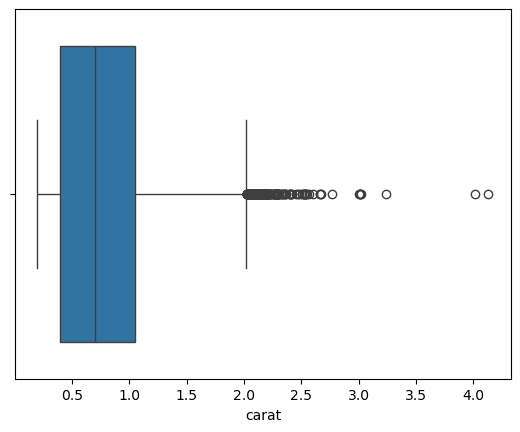

In [ ]:
# Boxplot for carat
sns.boxplot(x=df["carat"])
plt.show()

# Remove extreme outliers
df = df[df["carat"] <= 5]


In [7]:
# Ordinal encoding for cut, colour, clarity
ordinal_maps = {
    "cut": {"Fair":1, "Good":2, "Very Good":3, "Premium":4, "Ideal":5},
    "colour": {"J":1, "I":2, "H":3, "G":4, "F":5, "E":6, "D":7},
    "clarity": {"I1":1, "SI2":2, "SI1":3, "VS2":4, "VS1":5, "VVS2":6, "VVS1":7, "IF":8}
}

for col, mapping in ordinal_maps.items():
    df[col] = df[col].map(mapping)

# Encode target labels into numeric values
grade_map = {"Low": 0, "Mid": 1, "High": 2}
df["Grading"] = df["Grading"].str.strip().map(grade_map)

# Feature engineering
df["volume"] = df["Length"] * df["Width"] * df["height"]
df["carat_per_volume"] = df["carat"] / df["volume"]
df["aspect_ratio"] = df["Length"] / df["Width"]
df["table_depth_ratio"] = df["table"] / df["depth ratio"]

# Handle infinities and NaNs from feature engineering
df = df.replace([np.inf, -np.inf], np.nan)
df = df.fillna(df.median())


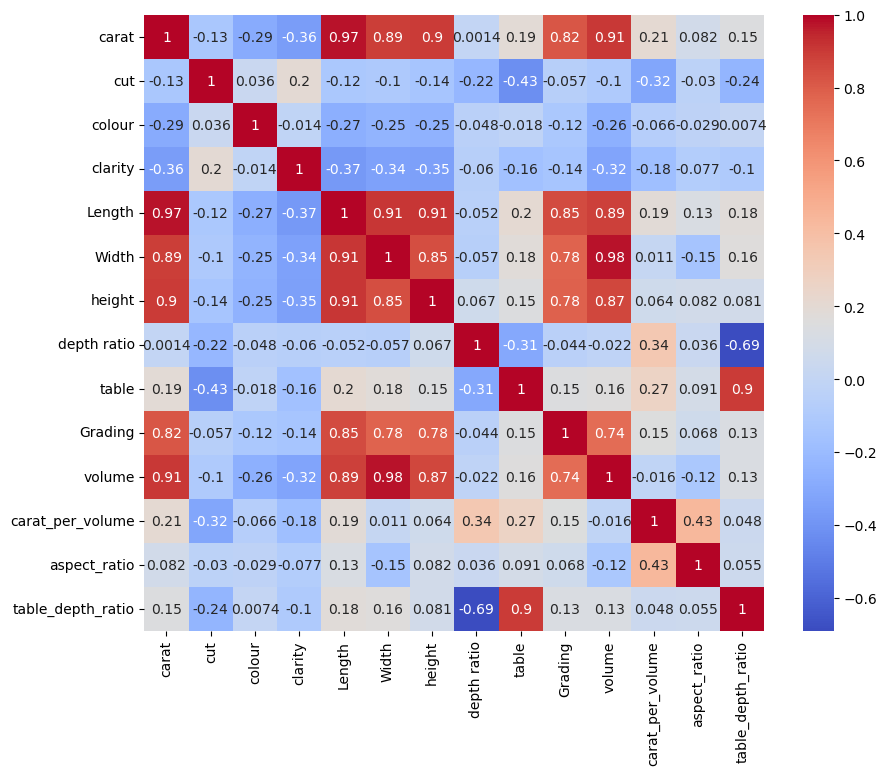

In [8]:
# Check correlation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [9]:
# Separate features and target
X = df.drop("Grading", axis=1)
y = df["Grading"]

# Train-test split (stratified to preserve Low/Mid/High balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(X_train_scaled.head())


      carat       cut    colour   clarity    Length     Width    height  \
0 -0.611945  0.976487  1.557146 -0.028824 -0.497362 -0.424770 -0.506854   
1  0.516217 -1.690361 -0.808993 -0.028824  0.582380  0.553043  0.705481   
2  0.641568  0.976487  0.374076 -0.028824  0.839040  0.789610  0.705481   
3  3.085921 -0.801411 -0.808993 -1.244447  2.317048  2.003990  2.243713   
4 -0.611945  0.976487  0.965611 -0.028824 -0.541614 -0.464198 -0.506854   

   depth ratio     table    volume  carat_per_volume  aspect_ratio  \
0    -0.665943 -0.200372 -0.520595         -0.862819     -0.329710   
1     1.332558  0.245208  0.428656          0.536651     -0.452522   
2    -0.597029 -0.200372  0.608830         -0.688612     -0.522555   
3     1.056903 -1.537111  2.659939          0.674251      0.545099   
4    -0.252460 -0.200372 -0.539156         -0.178567     -0.333147   

   table_depth_ratio  
0           0.135500  
1          -0.418650  
2           0.103884  
3          -1.598288  
4          -0

In [11]:
# Check mean and std after scaling
print(X_train_scaled.mean(axis=0))   # ~0
print(X_train_scaled.std(axis=0))    # ~1


carat               -7.734887e-17
cut                  9.779742e-17
colour               3.822990e-17
clarity              1.244694e-17
Length              -1.386945e-16
Width               -4.445337e-17
height              -1.242472e-16
depth ratio          2.260010e-15
table               -1.360273e-16
volume              -5.334405e-18
carat_per_volume    -1.831146e-15
aspect_ratio         4.223293e-15
table_depth_ratio   -2.151543e-16
dtype: float64
carat                1.000063
cut                  1.000063
colour               1.000063
clarity              1.000063
Length               1.000063
Width                1.000063
height               1.000063
depth ratio          1.000063
table                1.000063
volume               1.000063
carat_per_volume     1.000063
aspect_ratio         1.000063
table_depth_ratio    1.000063
dtype: float64


Random forest model

Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Best CV score: 0.9494487715648313

Class distribution in training set:
Grading
1    4329
0    2161
2    1502
Name: count, dtype: int64

Class distribution in test set:
Grading
1    1082
0     540
2     376
Name: count, dtype: int64

Train Accuracy: 0.993993993993994
Test Accuracy: 0.9414414414414415

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93       540
           1       0.95      0.94      0.95      1082
           2       0.94      0.94      0.94       376

    accuracy                           0.94      1998
   macro avg       0.94      0.94      0.94      1998
weighted avg       0.94      0.94      0.94      1998

Confusion Matrix:
[[ 510   30    0]
 [  42 1017   23]
 [   0   22  354]]


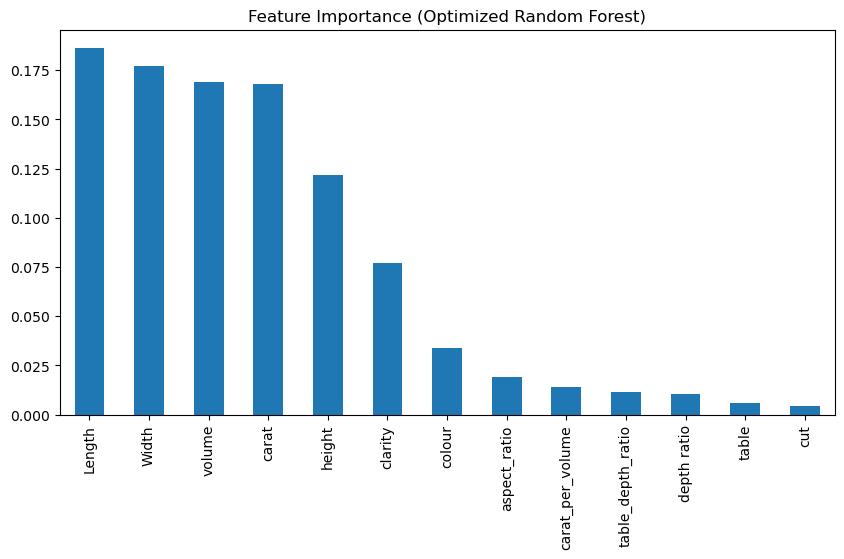


Cross-validation scores: [0.95559725 0.94871795 0.94430538 0.95494368 0.9436796 ]
Mean CV accuracy: 0.9494487715648313


In [12]:
# --- Random Forest with GridSearchCV ---

# Step 1: Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Step 2: Initialize base model
rf_base = RandomForestClassifier(random_state=42, class_weight="balanced")

# Step 3: Grid search with cross-validation
grid_search = GridSearchCV(rf_base, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# Step 4: Train optimized Random Forest with best parameters
rf_model = RandomForestClassifier(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    min_samples_split=grid_search.best_params_['min_samples_split'],
    max_features=grid_search.best_params_['max_features'],
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


# Step 5: Practical checks and evaluation
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

print("\nTrain Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Step 6: Feature importance
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False).plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance (Optimized Random Forest)")
plt.show()

# Step 7: Cross-validation check with optimized model
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)
print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


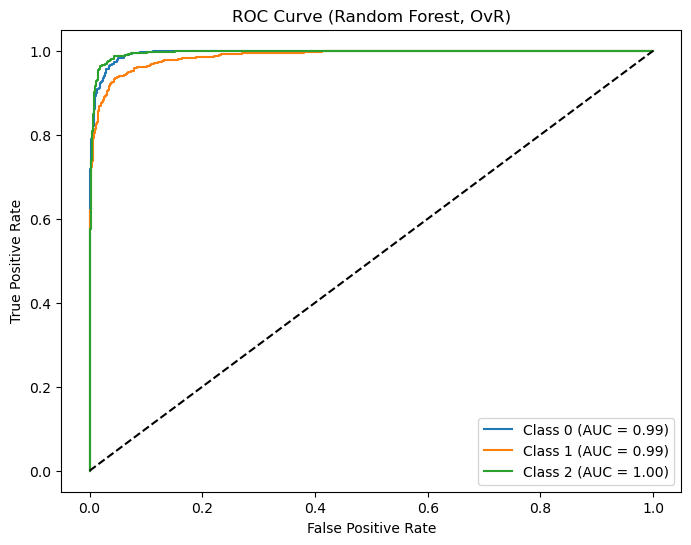

In [ ]:


# Step 8: ROC Curve (OvR, multi-class)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities
y_score = rf_model.predict_proba(X_test)

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--') 
plt.title("ROC Curve (Random Forest, OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


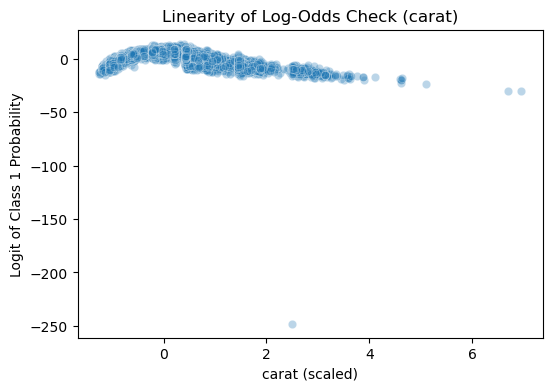

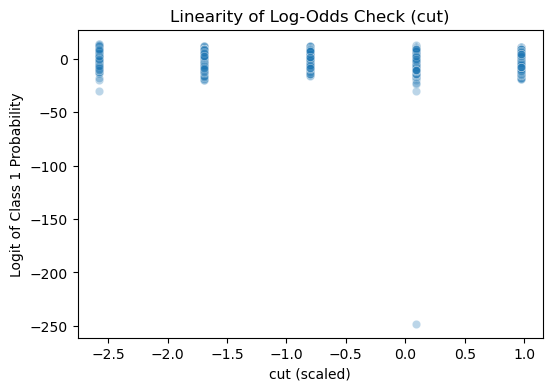

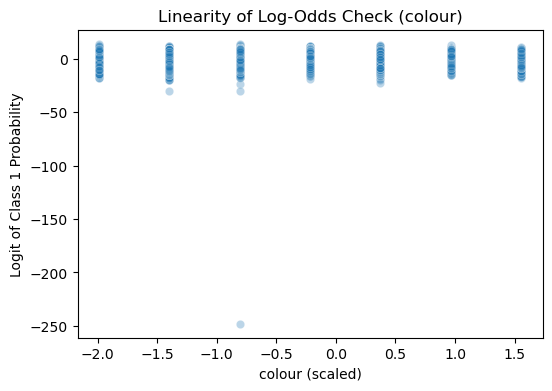

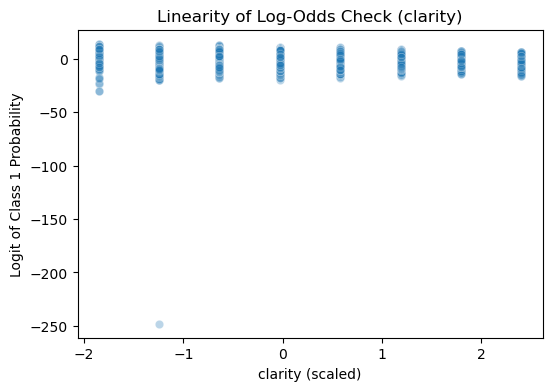

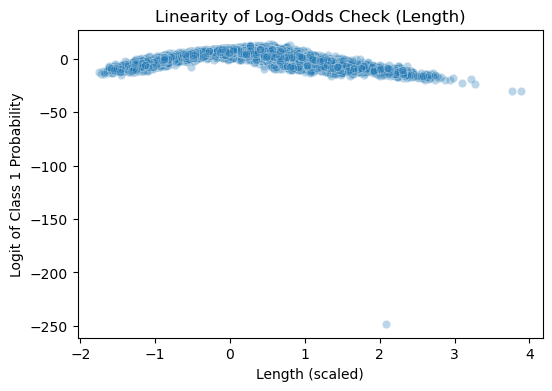

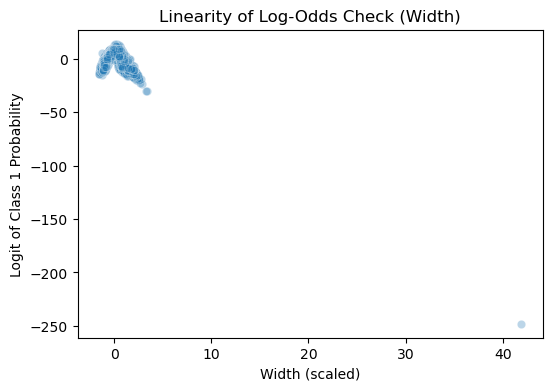

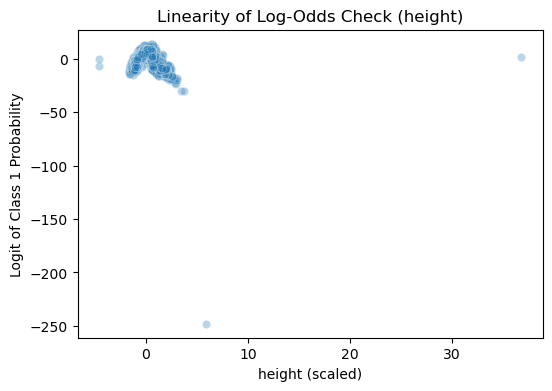

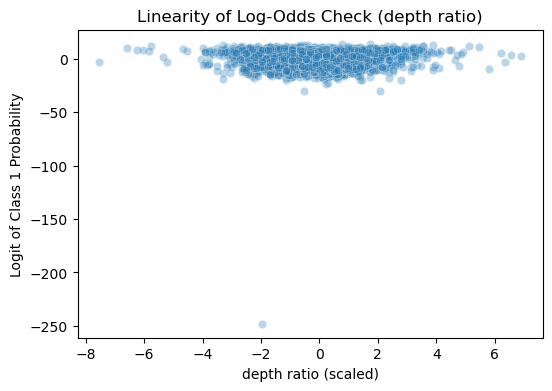

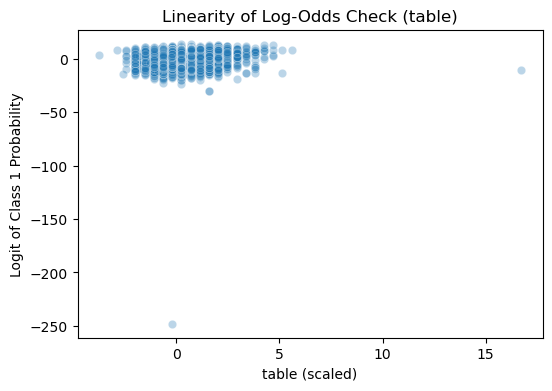

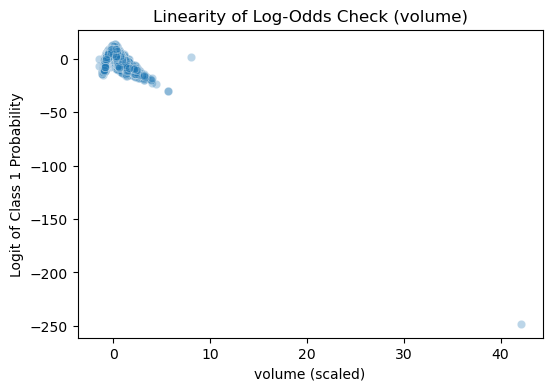

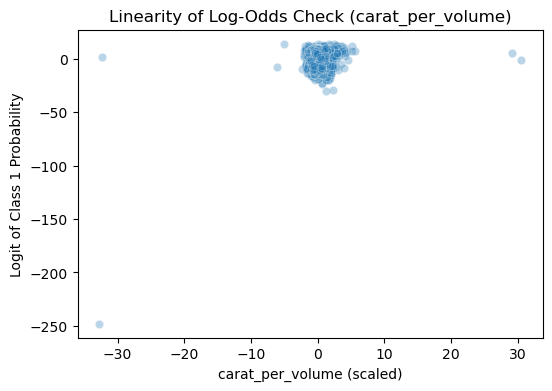

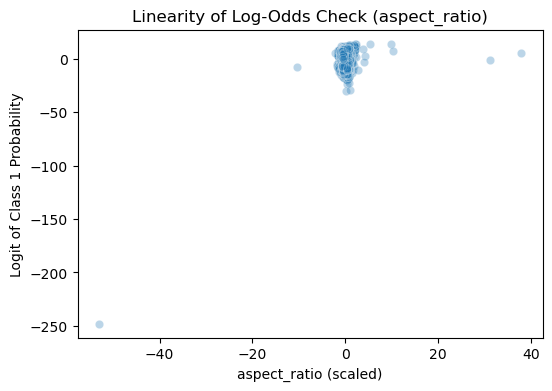

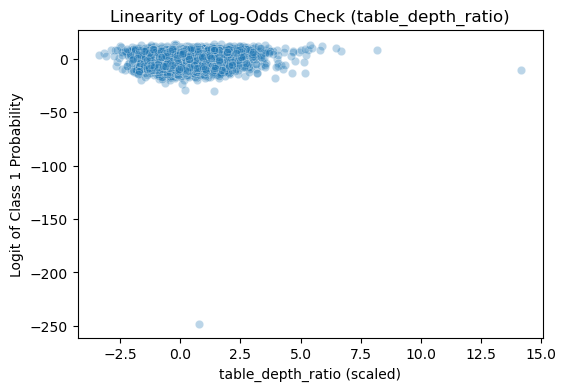


Variance Inflation Factors:
              feature         VIF
0               carat  529.885205
1                 cut    1.867660
2              colour    1.118884
3             clarity    1.236916
4              Length  849.519199
5               Width  754.089187
6              height   36.954933
7         depth ratio  144.846285
8               table  365.650843
9              volume  689.633754
10   carat_per_volume    4.008893
11       aspect_ratio    6.407159
12  table_depth_ratio  653.853126

Independence of observations check:
Duplicate rows in training set: 0
Duplicate rows in test set: 0

Train Accuracy: 0.9383133133133134
Test Accuracy: 0.9309309309309309

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93       540
           1       0.97      0.90      0.93      1082
           2       0.89      0.97      0.93       376

    accuracy                           0.93      1998
   macro avg       0.92     

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning


Cross-validation scores: [0.93558474 0.93871169 0.93929912 0.93804756 0.93491865]
Mean CV accuracy: 0.9373123533873253


In [ ]:
# --- Multinomial Logistic Regression ---

# --- Step 1: Assumption Verification ---

# --- Linearity of log-odds check ---

# Fit a temporary logistic regression model
log_reg_temp = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    multi_class="multinomial",
    max_iter=500
)
log_reg_temp.fit(X_train_scaled, y_train)

# Predicted probabilities
y_prob = log_reg_temp.predict_proba(X_train_scaled)

# Compute logit for one class 
logit_class1 = np.log(y_prob[:, 1] / (1 - y_prob[:, 1]))

# Loop through all continuous features and plot against logit
for feature in X_train_scaled.columns:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=X_train_scaled[feature], y=logit_class1, alpha=0.3)
    plt.xlabel(f"{feature} (scaled)")
    plt.ylabel("Logit of Class 1 Probability")
    plt.title(f"Linearity of Log-Odds Check ({feature})")
    plt.show()


# (b) Multicollinearity check (Variance Inflation Factor)
vif_data = pd.DataFrame()
vif_data["feature"] = X_train.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_scaled.values, i)
    for i in range(X_train_scaled.shape[1])
]
print("\nVariance Inflation Factors:")
print(vif_data)

# (c) Independence of observations
duplicates_train = X_train.duplicated().sum()
duplicates_test = X_test.duplicated().sum()
print("\nIndependence of observations check:")
print(f"Duplicate rows in training set: {duplicates_train}")
print(f"Duplicate rows in test set: {duplicates_test}")

# --- Step 2: Train Logistic Regression Model ---
log_reg_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    multi_class="multinomial",
    max_iter=500
)
log_reg_model.fit(X_train_scaled, y_train)

# --- Step 3: Predictions ---
y_pred_lr = log_reg_model.predict(X_test_scaled)

# --- Step 4: Evaluation ---
print("\nTrain Accuracy:", log_reg_model.score(X_train_scaled, y_train))
print("Test Accuracy:", log_reg_model.score(X_test_scaled, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

# --- Step 5: Cross-validation check ---
cv_scores = cross_val_score(log_reg_model, X_train_scaled, y_train, cv=5)
print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


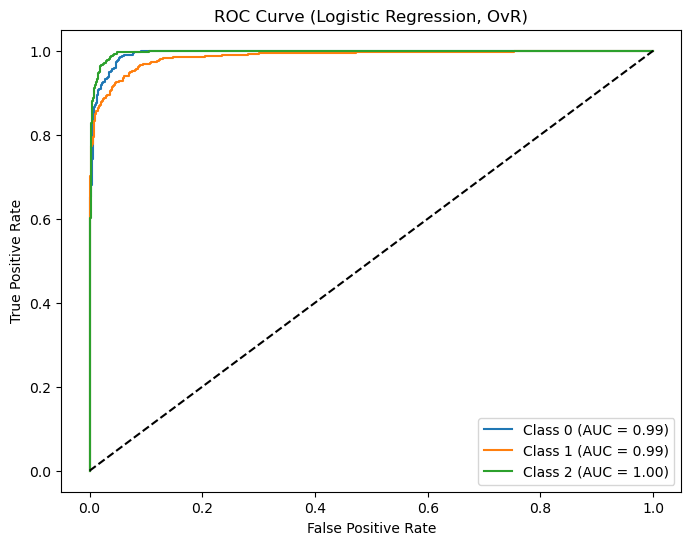

In [23]:
# Step 6: ROC Curve (OvR, multi-class)
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities
y_score = log_reg_model.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.title("ROC Curve (Logistic Regression, OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()


Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV score: 0.9468212689251182

Train Accuracy: 0.9593343343343343
Test Accuracy: 0.9474474474474475

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       540
           1       0.97      0.93      0.95      1082
           2       0.92      0.98      0.95       376

    accuracy                           0.95      1998
   macro avg       0.94      0.96      0.95      1998
weighted avg       0.95      0.95      0.95      1998

Confusion Matrix:
[[ 516   24    0]
 [  44 1007   31]
 [   0    6  370]]


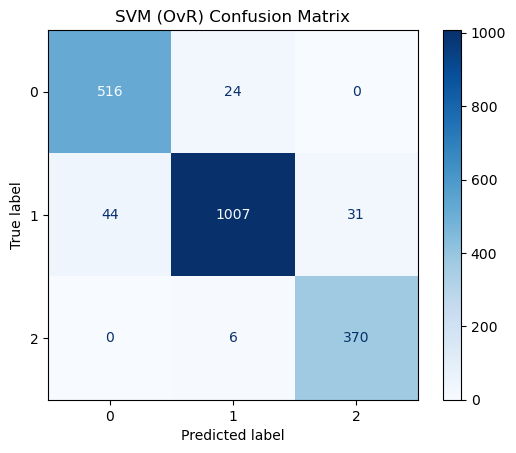

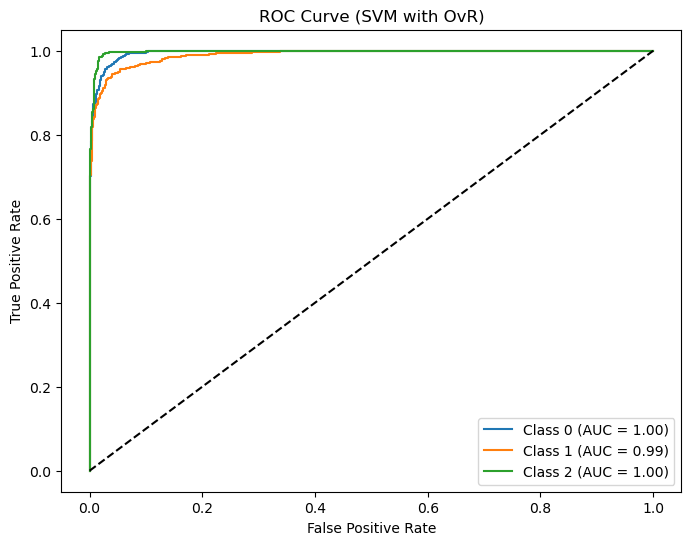


Cross-validation scores: [0.9449656  0.95309568 0.94430538 0.94931164 0.94242804]
Mean CV accuracy: 0.9468212689251182


In [ ]:
# --- SVM with OvR Strategy ---

# Step 1: Define parameter grid
param_grid = {
    'kernel': ['linear', 'rbf'],   # linear for separable, rbf for non-linear
    'C': [0.1, 1, 10],             # regularization strength
    'gamma': ['scale', 'auto']     # kernel coefficient (relevant for rbf)
}

# Step 2: Initialize base model with probability=True
svm_base = SVC(
    decision_function_shape='ovr',
    random_state=42,
    class_weight="balanced",
    probability=True
)

# Step 3: Grid search with cross-validation
grid_search = GridSearchCV(svm_base, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

# Step 4: Train optimized SVM with best parameters
svm_model = SVC(
    kernel=grid_search.best_params_['kernel'],
    C=grid_search.best_params_['C'],
    gamma=grid_search.best_params_['gamma'],
    decision_function_shape='ovr',
    random_state=42,
    class_weight="balanced",
    probability=True
)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

# Step 5: Evaluation
print("\nTrain Accuracy:", svm_model.score(X_train_scaled, y_train))
print("Test Accuracy:", svm_model.score(X_test_scaled, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

# --- Confusion Matrix Plot ---
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp_svm.plot(cmap='Blues', values_format='d')
plt.title("SVM (OvR) Confusion Matrix")
plt.show()

# Step 5b: ROC Curve (OvR, multi-class)

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
n_classes = y_test_bin.shape[1]

# Get predicted probabilities
y_score = svm_model.predict_proba(X_test_scaled)

plt.figure(figsize=(8,6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (SVM with OvR)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

# Step 6: Cross-validation check with optimized model
cv_scores = cross_val_score(svm_model, X_train_scaled, y_train, cv=5)
print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Train Accuracy: 0.8567317317317318
Test Accuracy: 0.8528528528528528

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.97      0.90       540
           1       0.90      0.82      0.86      1082
           2       0.77      0.77      0.77       376

    accuracy                           0.85      1998
   macro avg       0.83      0.85      0.84      1998
weighted avg       0.86      0.85      0.85      1998

Confusion Matrix:
[[523  17   0]
 [105 891  86]
 [  0  86 290]]

Cross-validation scores: [0.85991245 0.85178236 0.86357947 0.85231539 0.85481852]
Mean CV accuracy: 0.8564816401990919


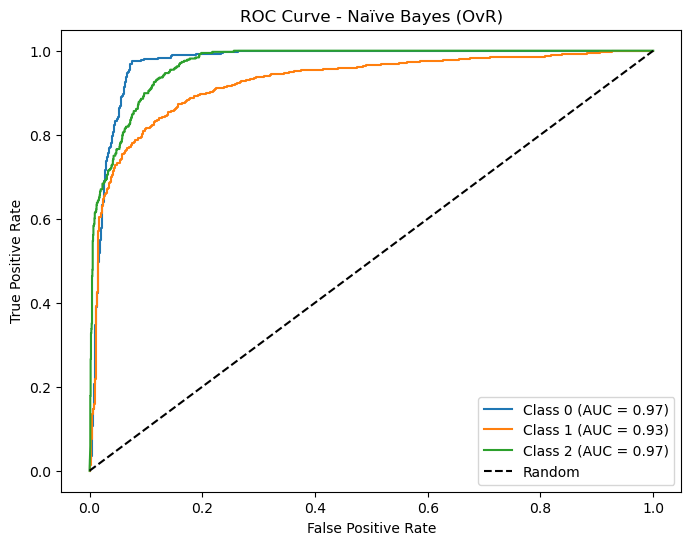

In [ ]:
# --- Naïve Bayes Classifier ---

# Step 1: Initialize Naïve Bayes model
nb_model = GaussianNB()

# Step 2: Train the model
nb_model.fit(X_train_scaled, y_train)

# Step 3: Predictions
y_pred_nb = nb_model.predict(X_test_scaled)

# Step 4: Evaluation
print("Train Accuracy:", nb_model.score(X_train_scaled, y_train))
print("Test Accuracy:", nb_model.score(X_test_scaled, y_test))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_nb))

# Step 5: Cross-validation check
cv_scores = cross_val_score(nb_model, X_train_scaled, y_train, cv=5)
print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

# Step 6: ROC Curve (One-vs-Rest for multi-class)
classes = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = nb_model.predict_proba(X_test_scaled)

# Plot ROC curve for each class
plt.figure(figsize=(8,6))
for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_label} (AUC = {roc_auc:.2f})")

# Plot diagonal line for random classifier
plt.plot([0, 1], [0, 1], "k--", label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naïve Bayes (OvR)")
plt.legend(loc="lower right")
plt.show()


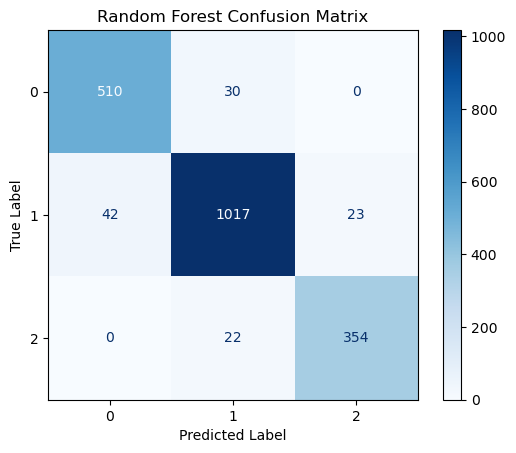

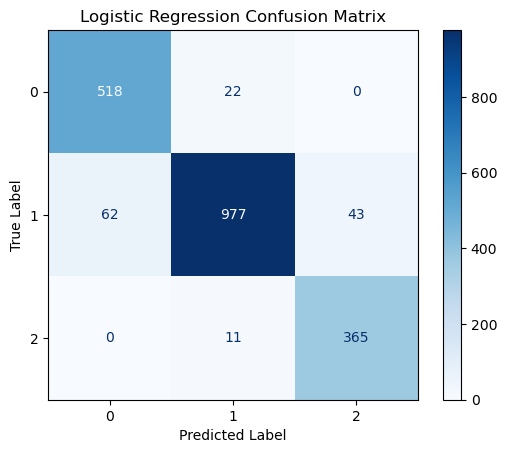

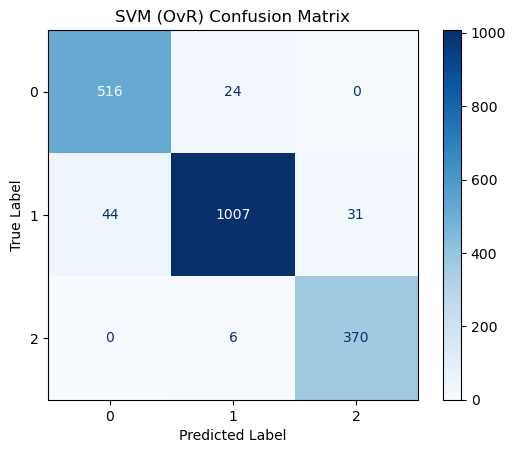

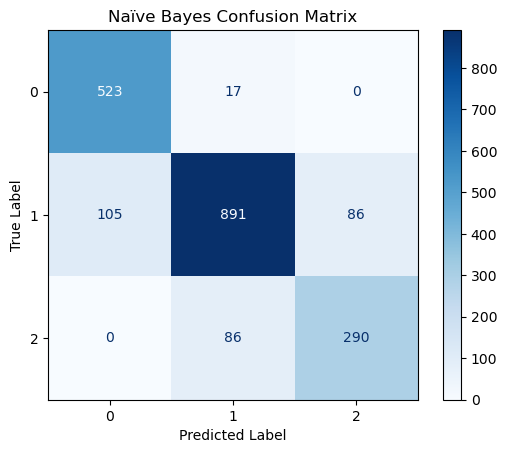

In [28]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

# Random Forest
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

# Logistic Regression
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

# SVM
plot_confusion_matrix(y_test, y_pred_svm, "SVM (OvR)")

# Naïve Bayes
plot_confusion_matrix(y_test, y_pred_nb, "Naïve Bayes")
